# Multilayer Artificial Neural Network

In [ ]:
# Environment

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array
from sklearn.utils.multiclass import shuffle

# 1. Notation and Structure of Multilayer Perceptron (MLP)

A Multilayer Perceptron (MLP) is a special type of **fully connected network**, usually consisting of an input layer, one or more hidden layers, and an output layer. 
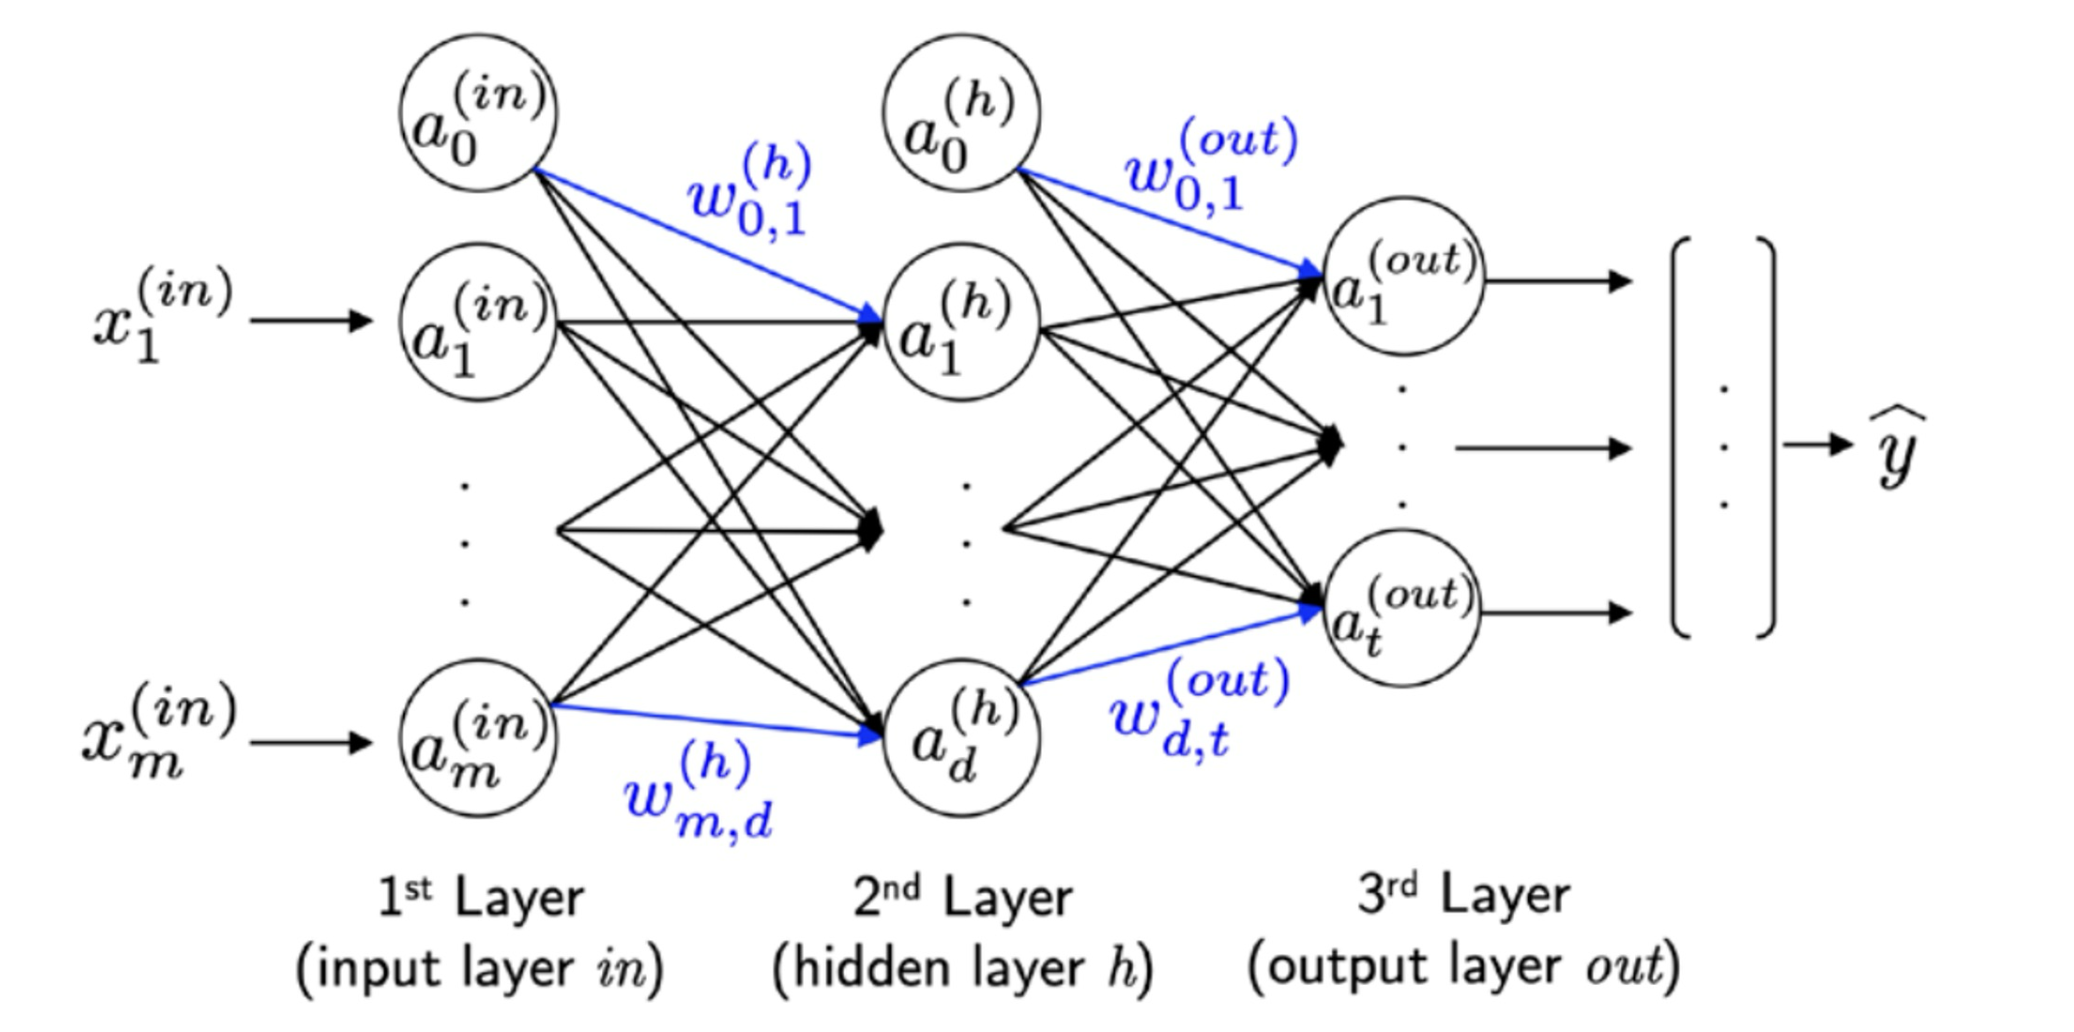

We conveniently use the following notations:
+ $a_i^{(l)}$: the activation of the $i$-th neuron in the $l$-th layer.
+ $\hat{a}^{(l)}$: the vector of activations in the $l$-th layer.
+ $w_{i,j}^{(l)}$: the weight connecting the $j$-th neuron in the $(l-1)$-th layer to the $i$-th neuron in the $l$-th layer.
+ $in$: the input layer
+ $m$: the number of neurons in the input layer(excluding the bias unit)
+ $h$: the hidden layer
+ $d$: the number of neurons in the hidden layer(excluding the bias unit)
+ $out$: the output layer
+ $t$: the number of neurons in the output layer(excluding the bias unit)
+ $z$: the pre-activation value

The definition of MLP and deep learning is a little bit confusing. In some textbooks, MLP is defined that only one hidden layer is allowed, and deep learning is defined that more than one hidden layer is allowed. However, in practice, MLP is often used to refer to any fully connected network, regardless of the number of hidden layers. We follow the definition of the HKU COMP3314 course, which defines MLP only has one hidden layer, and deep learning has more than one hidden layer.

# 2. The process of MLP
Here are two main process of MLP:
1. **Forward Propagation**: The input data is passed through the network layer by layer, and the output is computed.
2. **Backward Propagation**: The error is propagated back through the network to update the weights.

## 2.1 Forward Propagation
+ The forward propagation process is same as in perceptron, or we can say that each neruon in the MLP is a perceptron:
+ For a neuron $a_i^{(l)}$, we have the following equations:
  + If $a_i^{(l)}$ is in input layer, then $a_i^{(l)}$ is just the input feature, and $z_i^{(l)}$ is not defined.
  + If $a_i^{(l)}$ is in output layer, then $a_i^{(l)}$ is the output of the network, and $z_i^{(l)}$ is the pre-activation value of the output layer.
  + Otherwise if $a_i^{(l)}$ is in hidden layer, we have:
    + The pre-activation value $z_i^{(l)}$ is computed as the weighted sum of the activations from the previous layer:
      $$z_i^{(l)} = \sum_{j=0} w_{j,i}^{(l)} a_j^{(l-1)}$$
    + The activation $a_i^{(l)}$ is computed by applying an activation function $\phi$ to the pre-activation value:
      $$a_i^{(l)} = \phi(z_i^{(l)})$$
+ To solve the complex problem(i.e. non-linear), the activation function $\phi$ is usually a non-linear function, such as sigmoid, tanh, ReLU, etc. The choice of activation function can affect the performance of the network.
  + e.g. $$\phi(z) = \frac{1}{1 + e^{-z}}$$
+ MLP is a typical **feedforward neural network**, which means that the information flows in one direction, from the input layer to the output layer, without any cycles or loops. The results($z$) of each layer are only used as input for the next layer.
+ For convenience of computation, we often vectorize the equations:
  + The process of forward propagation can be written as:
    $$
    \begin{aligned}
    &\bold{A}^{(in)}=[b^{(in)}, \bold{X}]^T\\
    &\bold{Z}^{(h)} = \bold{W}^{(h)} \bold{A}^{(in)}\\
    &\bold{A}^{(h)} = [b^{(h)}, \phi(\bold{Z}^{(h)})]^T\\
    &\bold{Z}^{(out)} = \bold{W}^{(out)} \bold{A}^{(h)}\\
    &\bold{A}^{(out)} = \phi(\bold{Z}^{(out)})
    \end{aligned}
    $$
  + More generally, for each layer $l$, we have:
    $$
    \begin{aligned}
    &\bold{Z}^{(l)} = \bold{W}^{(l)} \bold{A}^{(l-1)}\\
    &\bold{A}^{(l)} = [b^{(l)}, \phi(\bold{Z}^{(l)})]^T
    \end{aligned}
    $$


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward_propagation(X, Ws, bs, activation=sigmoid):
    "The real forward propagation implementation in MLP is more complex, but this is a simplified version to illustrate the concept."
    A = X
    for W, b in zip(Ws, bs):
        Z = A @ W + b
        A = activation(Z)
    return A

## 2.2 Backward Propagation
+ **Core Idea**:
  1. Count the error/loss at the output layer.
  2. Compute the gradient of the loss with respect to the weights in the output layer(partial derivatives).
  3. Propagate the error back to the hidden layer, update the weights in the hidden layer.
+ The essential part of backpropagation is that:
  + The loss function of multiple layers always non-convex and non-smooth, which makes it hard to optimize.
  + Is complex and computationally expensive to directly compute the gradient of the loss.
+ We consider to use the **chain rule** and **Automatic Differentiation** tosolve it:
+ **Chain Rule**:
  + For the composite function $f(g(x))$, the derivative is computed as:
    $$\frac{df}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}$$
  + The network can be seen as a composite function:
    + $\bold{A}^{(out)} = \phi(\bold{A}^{(h)} \bold{W}^{(out)}) = \phi(\phi(\bold{A}^{(in)} \bold{W}^{(h)}) \bold{W}^{(out)})$
  + Hence we can compute the gradient of the loss by applying the chain rule layer by layer.
### 2.2.1 Definition of Automatic Differentiation
There are two traditional methods to compute the gradient of the loss:
+  **Symbolic Differentiation**:
   + If we have the clear mathematical expression of the function, we can directly compute the derivative by using the rules of differentiation.
   + Pros:
     + High precision
   + Cons:
     + Computationally expensive.
     + Only works for simple functions.
+ **Numerical Differentiation**:
   + We can approximate the derivative by using the finite difference method:
     $$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$
   + Pros:
     + Easy to implement.
     + Works for any function.
   + Cons:
     + Low precision, especially when $h$ is small.
     + Computationally expensive, especially for high-dimensional functions.
Note that each complex computer program can be regarded as a composition of simple operations, we can apply the chain rule to compute total derivative of the program by computing the derivatives of each simple operation. This is the idea of **Automatic Differentiation** (AD), which is a technique to compute the derivative of a function defined by a computer program. 

+ According to the order of computation, there are two modes of AD:
  + **Forward Mode**:
    + Follow the calculation order of the original function, computating the derivative respect to **certain input variable** while computeing the function value.
  + **Reverse Mode**: Here are two main steps of reverse mode AD:
    1. Follow the calculation order of the original function, compute the function value and store the intermediate results.
    2. Follow the reverse order of the original function, compute the derivative respect to **certain output variable** while using the stored intermediate results.

In AD, we decompose the function into a sequence of **Primitive Operations** as:
+ Basic arithmetic operations: addition, subtraction, multiplication, division, etc.
+ Elementary functions: exponential, logarithm, trigonometric functions, etc.
+ Other common functions: max, min, abs, etc.
+ Control flow operations: if-else, loops, etc.
The derivative of each primitive operation is known and can be computed efficiently. By structuring the function into a graph of primitive operations, we can apply the chain rule to compute the derivative of the entire function efficiently.

e.g. For the function $f(x,y,z)=(x+1)(y+sin(z))(x^2+y^z)$

```mermaid
graph TD
    A[z] -->E[sin]
    B[x] --> J[+]
    C[1] --> J[+]
    D[y] --> K[+]
    E[sin] --> K[+]
    F[x] --> L[^]
    G[2] --> L[^]
    H[y] --> M[^]
    I[z] --> M[^]
    J[+] --> N[*]
    K[+] --> N[*]
    L[^] --> O[+]
    M[^] --> O[+]
    N[*] --> P[*]
    O[+] --> P[*]
```
### 2.2.2 Process of Forward AD
1. Start with the input variables, compute and store the direct derivatives of them with respect to a certain input variable.
   1. Obviously, the direct derivative of an input variable with respect to itself is 1, and the direct derivative of an input variable with respect to other input variables is 0.
2. Repeatedly apply the chain rule to compute the derivatives of all primitive operations that all father nodes have been computed, until we reach the output variable.

### 2.2.3 Process of Reverse AD
1. Forward pass: Start with the input variables, compute and store the value of each primitive operation until we reach the output variable.
2. Backward pass: Start with the output variable:
   1. We define the **adjoint variable** $\hat{v_i} = \frac{\partial f}{\partial v_i}$ for each primitive operation $v_i$.
   2. Suppose a primitive operation $v_i=g(v_j, v_k)$, and we already know the adjoint variable $\hat{v_i}$, then we can accumulate the adjoint variables of $v_j$ and $v_k$ as:
      + $\hat{v_j} += \hat{v_i} \cdot \frac{\partial g}{\partial v_j}$
      + $\hat{v_k} += \hat{v_i} \cdot \frac{\partial g}{\partial v_k}$
   3. We repeatedly apply this process until we reach the input variables, and we can obtain the derivatives of the output variable with respect to each input variable.

After those definitions and techniques, we can implement our MLP like this:

In [ ]:
class MyMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, 
                 hidden_layer_sizes=(100,), 
                 activation='sigmoid',
                 learning_rate=0.01,
                 mini_batch_size=32,
                 max_iter=200,
                 random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        if activation == 'sigmoid':
            self.activation_func = self.sigmoid
            self.derivative_activation_func = self.derivative_sigmoid
        elif activation == 'tanh':
            self.activation_func = self.tanh
            self.derivative_activation_func = self.derivative_tanh
        elif activation == 'relu':
            self.activation_func = self.relu
            self.derivative_activation_func = self.derivative_relu
        elif activation == 'softmax':
            self.activation_func = self.softmax
            self.derivative_activation_func = self.derivative_softmax
        else:
            raise ValueError("Unsupported activation function.")、
        self.learning_rate = learning_rate
        self.mini_batch_size = mini_batch_size
        self.max_iter = max_iter
        self.random_state = random_state
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def derivative_sigmoid(self, y):
        return y * (1 - y)
    
    def tanh(self, z):
        return np.tanh(z)
    
    def derivative_tanh(self, y):
        return 1 - y ** 2
    
    def relu(self, z):
        return np.maximum(0, z)
    
    def derivative_relu(self, y):
        return (y > 0).astype(float)
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def _initialize(self):
        self.bs = []
        self.Ws = []
        for i in range(len(self.layershape_) - 1):
            fan_in = self.layershape_[i]
            fan_out = self.layershape_[i+1]
            factor = 2.0
            init_bound = np.sqrt(factor / (fan_in + fan_out))
            W = np.random.uniform(-init_bound, init_bound, (fan_in, fan_out))
            b = np.zeros(fan_out)
            self.bs.append(b)
            self.Ws.append(W)
            
    def _forward_pass(self, Xs):
        As = [Xs]
        Zs = [[]]
        for i in range(len(self.layershape_) - 2):
            W = self.Ws[i]
            b = self.bs[i]
            Z = As[-1] @ W + b
            As.append(self.activation_func(Z))
            Zs.append(Z)
            
        W = self.Ws[-1]
        b = self.bs[-1]
        Z = As[-1] @ W + b
        As.append(self.softmax(Z))
        Zs.append(Z)
        return As, Zs
    
    def _backward_pass(self, As, Zs, ys):
        ys_one_hot = np.zeros_like(As[-1])
        ys_one_hot[np.arange(len(ys)), ys] = 1
        D = [As[-1] - ys_one_hot]
        
        for l in range(len(self.layershape_) - 2, 0, -1):
            dA = D[-1] @ self.Ws[l].T
            dZ = dA * self.derivative_activation_func(As[l])
            D.append(dZ)
        D.reverse()
        return D
            
    def _update_weights(self, Xs, ys):
        As, Zs = self._forward_pass(Xs)
        D = self._backward_pass(As, Zs, ys)
        for i in range(len(self.layershape_) - 1):
            self.Ws[i] -= self.learning_rate * As[i].T @ D[i]
            self.bs[i] -= self.learning_rate * np.sum(D[i], axis=0)
        
    def fit(self, Xs, ys):
        Xs, ys = check_X_y(Xs, ys, copy=True)
        self.classes_ = np.unique(ys)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = Xs.shape[1]
        self.layershape_ = [self.n_features_] + list(self.hidden_layer_sizes) + [self.n_classes_]
        self._initialize()
        
        for iteration in range(self.max_iter):
            for start in range(0, Xs.shape[0], self.mini_batch_size):
                end = np.min(start + self.mini_batch_size, Xs.shape[0])
                X_batch = Xs[start:end]
                y_batch = ys[start:end]
                self._update_weights(X_batch, y_batch)
            Xs, ys = shuffle(Xs, ys, random_state=self.random_state)
        return self
    
    def predict(self, Xs):
        As, _ = self._forward_pass(Xs)
        return np.argmax(As[-1], axis=1)



